In [4]:
# Import Python package to display images in the notebook.
# Note if you run image cells the imge will disappear!
from IPython.display import Image, display

## 📁 Working with File Paths in JupyterLab and Google Colab

When your notebook uses images or data files, Python needs to know *where those files are*.  
The **path** tells Python how to find them.

### 🧭 What is a Path?

A **path** is like an address for a file.

- **Relative path** → file near your notebook  
  - Example: `images/sun.png` means there’s a folder called `images` next to your notebook, and inside it a file called `sun.png`.  
- **Absolute path** → full address of a file on your computer  
  - Windows: `C:\\Users\\Lauren\\Documents\\sun.png`  
  - macOS/Linux: `/Users/lauren/Documents/sun.png`

For sharing work, always prefer **relative paths** — they work for everyone!

### 💻 Using JupyterLab

- Your “home” folder is the one you see in the **File Browser**.  
- If your file is in the **same folder** as the notebook:  
  ```python
  "aia_wavelengths.png"
- If it is inside another folder:
  ```python
  "images/aia_wavelengths.png"
- To move up one folder level:
  ```python
  "../data/sun.csv"

### 🧩 Check where you are
  ```python
import os
os.getcwd()   # shows your current folder
os.listdir()  # shows the files inside it
```

### ☁️ Using Google Colab
Colab runs in the cloud — it starts in a temporary, empty folder. You can either upload files or connect to Google Drive. 

When downloading files inside a notebook on Colab, you can simply make the `path = '.'`. Or, upload files following the format below or by uploading them manually. 

#### 🔹 Upload a file from your computer


  ```python
from google.colab import files
uploaded = files.upload()
```
Then access it simply by name:
```python
"sun.csv"
```

### ✅ Quick Tips

- ✅ Keep images/data in the same folder as the notebook whenever possible.
- ✅ Use relative paths (images/sun.png) so they work for everyone.
- ⚠️ Files uploaded to Colab disappear when the session ends — save to Drive if you need them later.

---

# SOLAR II - Exploring the solar surface
Since our Sun is our nearest star we can observe its surface in great detail. In February 2010, NASA launched the __[Solar Dynamics Observatory (SDO)](https://sdo.gsfc.nasa.gov/)__ as part of their Living With a Star Program, designed to understand the causes of solar variability and its impacts on Earth. To achieve this, SDO has three instruments on board:
- Atmospheric Imaging Assembly (AIA)
- Helioseismic and Magnetic Imager (HMI)
- EUV Variability Experiment (EVE)

<div class="alert alert-block alert-info">
    
**GOAL :** In this session we are going to be using data from two of SDO's instruments, AIA and HMI, to explore how the surface of the Sun changes overtime. 

**AIM :** To understand how to access, manipulate and plot images of the solar surface. 

**OUTPUT :** Create maps and animations of regions of the solar surface which display different types of phenomena.
</div>

## Atmospheric Imaging Assembly (AIA) 

The Atmospheric Imaging Assembly (AIA) images the solar atmosphere in multiple wavelengths to link changes in the surface to interior changes. Each of these wavelengths probes a different temperature, which corresponds to a specific layer of the solar atmosphere. These wavelengths are as follows:

- **1700Å:** photosphere, 4,500 Kelvin
- **4500Å:** photosphere, 6,000 Kelvin
- **1600Å:** upper photosphere and transition region, 10,000 Kelvin
- **304Å:** transition region and chromosphere, 50,000 Kelvin
- **171Å:** upper transition region and quiet corona, 600,000 Kelvin
- **193Å:** Corona and hot flare plasma, 1 million Kelvin
- **211Å:** active regions, 2 million Kelvin
- **335Å:** active regions, 2.5 million Kelvin
- **94Å:** flaring regions, 6 million Kelvin
- **131Å:** flaring regions, 10 million Kelvin

For more details on the specific ions each wavelength corresponds to and key features to look out for, see __[The Sun Today blog](https://www.thesuntoday.org/sun/wavelengths/)__.
Each of these wavelengths has a specific colour associated with it when plotting to make identification easier, see the image below. 


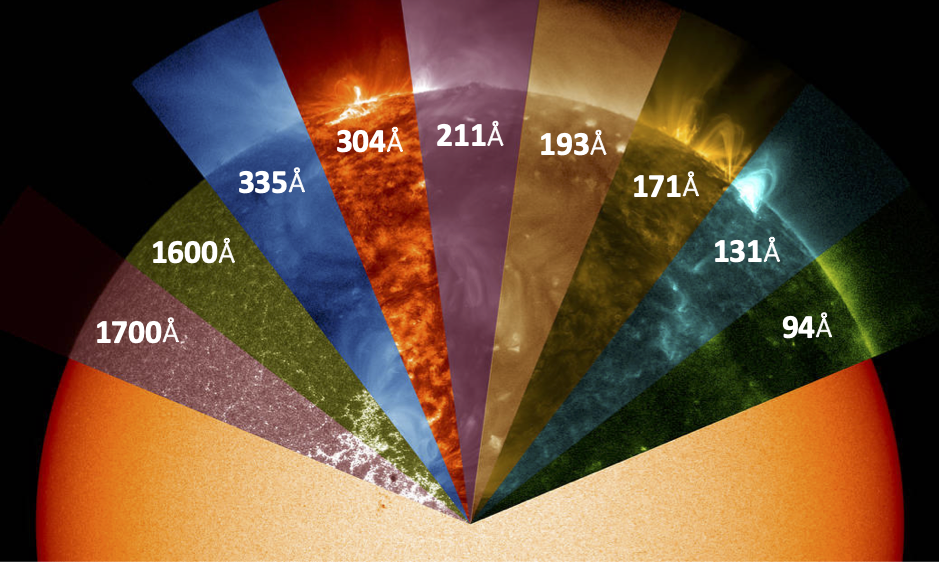

In [2]:
display(Image(filename="aia_wavelengths.png", embed=True))

**A couple of things to note:**
- An image of the Sun from AIA is taken in all 10 wavelengths every 10 seconds!
- Å represents the unit of Angstrom which is equivalent to 10<sup>-10</sup> m

## Helioseismic and Magnetic Imager (HMI)
The Helioseismic and Magnetic Imager (HMI) is an instrument designed to study oscillations and the magnetic field at the solar surface, or photosphere. HMI observes the full solar disk at 6173 Å with a resolution of 1 arcsecond and HMI Observables are taken every 45 seconds. There are three main types of data products for HMI.

<ins>Line-of-Sight Magnetograms</ins>

Magnetograms are maps of the observed solar magnetic field in the photosphere. The line-of-sight component of the field can be accurately measured as it evolves in time over the full visible disk of the Sun. The HMI instrument exploits the Zeeman effect (splitting of a spectral line into several components in the presence of a magnetic field), which allows the strength of the line-of-sight component of the magnetic field to be determined by measurements of the spectral line in circularly polarised light.

Use `a.Physobs.los_magnetic_field` when searching for data.

<ins>Continuum Intensitygrams</ins>

The HMI continuum data is a map of the continuum intensity of the solar spectrum which creates broad-wavelength photographs of the solar photosphere (i.e. solar surface). 

Use `a.Physobs.intensity` when searching for data.

<ins>Dopplergrams</ins>

HMI creates maps of the solar surface velocity. Blue areas represent plasma which is moving towards the observer (blue-shifted) and red areas represent plasma which is moving away from the observer (red-shifted). 

Use `a.Physobs.los_velocity` when searching for data.

**An example of each of the data products is shown in the image below.**

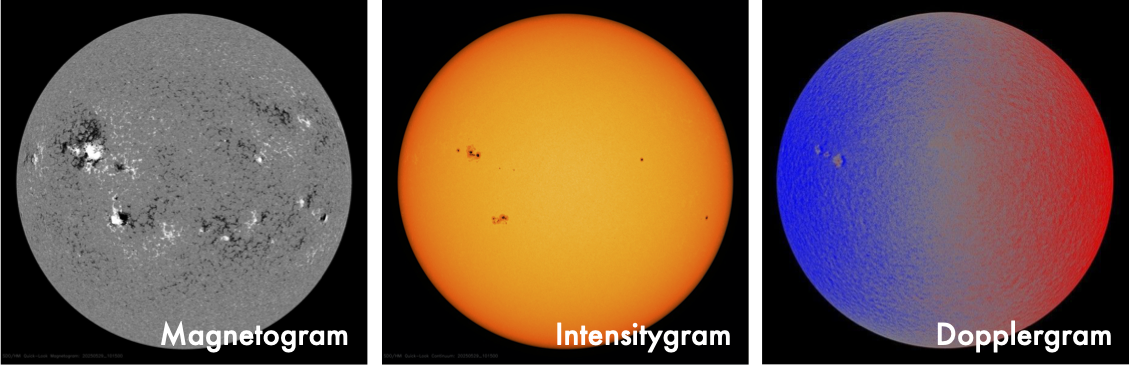

In [3]:
display(Image(filename="hmi_data.png", embed=True))

***

### Accessing SDO Data
In this session we will be focusing on using the __[SunPy](https://sunpy.org/)__ package where documentation and examples can be found on their website. 

Let's import the key Python packages that we will need.

In [2]:
# some basic packages
import os
import sys
import fnmatch
import numpy as np

# solar physics package
import sunpy

# importing plotting packages
import matplotlib.pyplot as plt
from matplotlib import dates

# setting text size for plots
import matplotlib as mpl
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['axes.titlesize'] = 12
mpl.rcParams['axes.labelsize'] = 12

# importing widgets for interactive plots
from ipywidgets import *

Data from SDO's AIA and HMI can be accessed from the Virtual Solar Observatory (VSO) through the Python sunpy package using the Fido interface which searchs for and downloads solar data. 

In [3]:
from sunpy.net import Fido
from sunpy.net import attrs as a
import astropy.units as u

To search for data with Fido, you need to specify attributes to search with. Examples of these are shown below:
    
- use a.Time to specify the data and time in the format 'yyyy/mm/dd hh:mm:ss' 
    > e.g. `a.Time('2025/10/01 00:00:15', '2025/10/01 00:00:30')`
    
- use a.Sample to get a series of data at a specific time interval during the range from a.Time
    > e.g. `a.Sample(1*u.h)`

- use the a.Instrument to specify which instrument you would like (i.e. AIA, HMI)
    > e.g. `a.Instrument.aia`
    
- search for specific physical observables using a.Physobs (see list above in HMI information)
    > e.g. `a.Physobs.los_magnetic_field`
    
- use a.wavelength to specify different 
    > e.g. `a.Wavelength(171*u.angstrom)`
    

<div class="alert alert-block alert-danger">
<b>WARNING:</b> During this session, we will be downloading data from the VSO using Fido within Python. This involves requesting data from the server and downloading it locally to your machine. With this in mind, please be patient when making search requests and downloading data. If you have any errors, please try again. If you continually have issues, then let a demonstrator know who will give you access to the data. 
</div>

### Example:

Putting this all together, search for AIA images on Christmas Day 2024 at 9 am with a wavelength of 131 angstroms.

```python
result = Fido.search(a.Time('2024/12/25 09:00:00', '2024/12/25 09:00:15'),
                     a.Instrument('aia'),
                     a.Wavelength(131*u.angstrom))
print(result)
```
Once you have the data you are looking for, you can download it using fetch, giving the `path` where you would like the files to download.

```python
downloaded_files = Fido.fetch(result, path='your/path/here/{file}')
print(downloaded_files)
```

## Task II-1
- Access SDO AIA data at 171 angstroms close to 8pm UT from day 294 in the year 2014 and plot the resulting table.
- Download the data to a folder on your laptop called ThaiPASS/solar.

(**Tip:** to get the date in format YYYY-MM-DD, look up a Julian calendar)

---
### Sunpy Maps
Map objects hold the two-dimensional data which makes up the image along with the accompanying metadata such as the date, coordinates, wavelength etc. The primary advantage of using a Map object over a bare NumPy array is the ability to perform coordinate aware operations on the image, such as rotating the Map to remove the roll angle of an instrument or cropping a Map to a specific field of view. 

To create a __[Map](https://docs.sunpy.org/en/stable/tutorial/maps.html)__ from an Atmospheric Imaging Assembly (AIA) image we use the map package within sunpy which automatically detects the type of file as well as the the instrument associated with it.

```python
import sunpy.map
aiamap = sunpy.map.Map('your/path/aia_lev1_131a_2024_12_25t09_00_06_62z_image_lev1.fits')
```
We can inspect the Map object as a quicklook in Jupyter notebook to make sure this has worked correctly.
```python
aiamap
```
We can then plot the image using the code below. On top of the image, we have plotted the limb of the Sun and a grid following the Heliographic Stonyhurst coordinate system. 
Sometimes an AIA image may appear "dark" when plotted, as the colour scale accounts for a small set of pixels which are extremely bright. Therefore, we can use the keyword clip_interval to clip out pixels with extreme values. Below, we clip out the darkest 1% of pixels and the brightest 0.01% of pixels.

```python
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(projection=aiamap)
aiamap.plot(axes=ax, clip_interval=(1, 99.99)*u.percent)
aiamap.draw_limb(axes=ax)
aiamap.draw_grid(axes=ax)
plt.show()
```
You can also save Maps as PDF files using the following:
```python
fig.savefig('you/path/here/.filename.pdf')
```

## Task II-2
- Using the data downloaded from Task II -1, create a sunpy Map and plot the AIA image.


<div class="alert alert-block alert-warning">
<b>CHECKPOINT 1:</b> Find a demonstrator and show them your Map before progressing to the next task.
</div>

---
### Cropping a Map
To crop a Map you have to create a submap, specifying the top right corner and bottom left corner as SkyCoord objects of the area you want to crop. You can use the full map to get an idea on the rough location of these and then use trial and error to refine the area. 

For example, the code below isolates the active region on the East limb of the Sun:

```python
from astropy.coordinates import SkyCoord

# defining the top_right and bottom_left corners
top_right = SkyCoord(-750 * u.arcsec, 500 * u.arcsec, frame=aiamap.coordinate_frame)
bottom_left = SkyCoord(-900 * u.arcsec, 300 * u.arcsec, frame=aiamap.coordinate_frame)

# creating the submap
aia_submap = aiamap.submap(bottom_left, top_right=top_right)
```
This can then be plotted in the same way as all the other Maps.

```python
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(projection=aia_submap)
aia_submap.plot(axes=ax)
aia_submap.draw_limb(axes=ax)
aia_submap.draw_grid(axes=ax)

# Make some room and put the title at the top of the figure
ax.set_position([0.1, 0.1, 0.8, 0.7])
ax.set_title(ax.get_title(), pad=45)

plt.show()
```

## Task II-3
- Using the image created from Task II-2, crop the image to select an area which shows an active region of your choice

    (**Tip:** This may require trial and error, so take your time!)


---
### HMI Magnetograms
In addition to the Maps from AIA, we can also get HMI Maps, showing the magnetic field strength across the solar surface. Here we will search for line-of-sight magnetograms in the 45-second cadence, close to the time the AIA images were taken, to view the strength of the magnetic field across the solar surface.

```python
result = Fido.search(a.Time('2024/12/25 09:00:00', '2024/12/25 09:00:30'),
                     a.Instrument('hmi'),
                     a.Physobs.los_magnetic_field)
print(result)
downloaded_files = Fido.fetch(result, path='your/path/here/{file}')
print(downloaded_files)
```

We can then create a map object using the same method as previously for AIA data, but normalise the colour scale. 
```python
hmimap = sunpy.map.Map('your/path/hmi_m_45s_2024_12_25_09_01_30_tai_magnetogram.fits')

# normalise the image between -200 and 200 to make features stand out
hmimap.plot_settings['norm'] = plt.Normalize(-200, 200)
```

Finally, we can plot the HMI map to inspect it. 
```python
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(projection=hmimap)
hmimap.plot(axes=ax)
plt.show()
```

We can also plot both HMI and AIA maps side by side. The HMI image is oriented “upside down” relative to the AIA image so, to correct for this, we can set `autoalign=True` and give the HMI image the projection of the AIA image, allowing us to plot the HMI image onto axes defined by the AIA reference frame.

```python 
fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(121, projection=aiamap)
aiamap.plot(axes=ax1, clip_interval=(1, 99.9)*u.percent)
ax2 = fig.add_subplot(122, projection=aiamap)
hmimap.plot(axes=ax2, autoalign=True, title='HMI image in AIA reference frame')
ax2.axis(ax1.axis())
plt.show()
```

## Task II-4
- Download the matching HMI line-of-sight magnetogram for the same date as Task II-1
- Create a second Map object using the HMI magnetogram and plot the HMI image
- Correct the HMI Map to use the AIA reference frame and plot the AIA and HMI Maps side by side.

## **Additional Questions** 

Using the plot you have just created above:
- What do you see in both images?
- What information does each image give you about the solar surface?
  
<div class="alert alert-block alert-warning">
<b>CHECKPOINT 2:</b> Find a demonstrator and show them your AIA/HMI comparison, discussing your findings before progressing to the next task.
</div>

---
### HMI Intensitygrams
In addition to magnetograms, HMI data products also include intensitygrams. We can download these as well and plot them to see surface features on the solar surface. 
```python
result_int = Fido.search(a.Time('2024/12/25 09:00:00', '2024/12/25 09:00:30'),
                     a.Instrument('hmi'),
                     a.Physobs.intensity)
print(result_int)
downloaded_int = Fido.fetch(result_int, path='your/path/here/{file}')
```

Create a map of the intensity and plot.
```python
hmi_int_map = sunpy.map.Map('your/path/here/hmi.ic_45s.2024.12.25_09_01_30_TAI.continuum.fits')
hmi_int_cmap = mpl.colormaps['hinodesotintensity'] # selecting colormap
hmi_int_map = hmi_int_map.rotate(order=3) # rotating the map

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(projection=hmi_int_map)
hmi_int_map.plot(axes=ax, autoalign=True, cmap = hmi_int_cmap)
plt.show()
```
## Task II-5
- Create a 1 x 3 plot showing the HMI magnetogram, intensitygram and AIA 171 map, using the HMI data downloaded in the previous task.
- What do you see in all of these images, and how do they relate to each other?

<div class="alert alert-block alert-warning">
<b>CHECKPOINT 3:</b> Find a demonstrator and show them your comparison plots.
</div>

---
## Task II-6 (optional)
Using everything you have learned about accessing, plotting and manipulating SDO data from HMI and AIA:
1. Explore the layers of the solar surface and the corresponding magnetic field structure of the solar event which occurred on 24/10/2014. To achieve this, download and plot the AIA and HMI data. You may want to consider other wavelengths than those we have explored so far. 

**Tip:** You may want to use __[Helioviewer](https://gs671-suske.ndc.nasa.gov/)__ to pinpoint the times of the event before you download the data. 